Task 5: Decision Trees and Random Forests

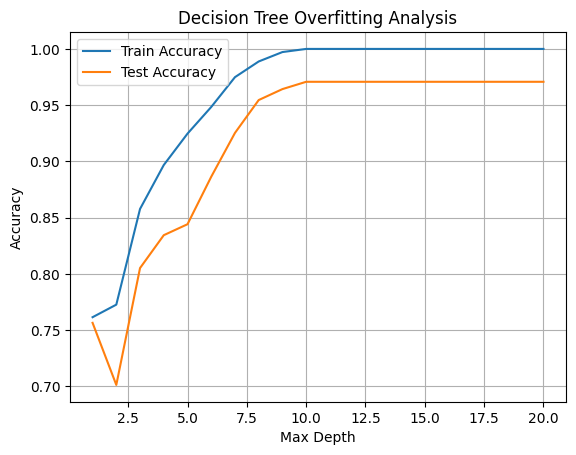

Random Forest Accuracy: 0.9805194805194806


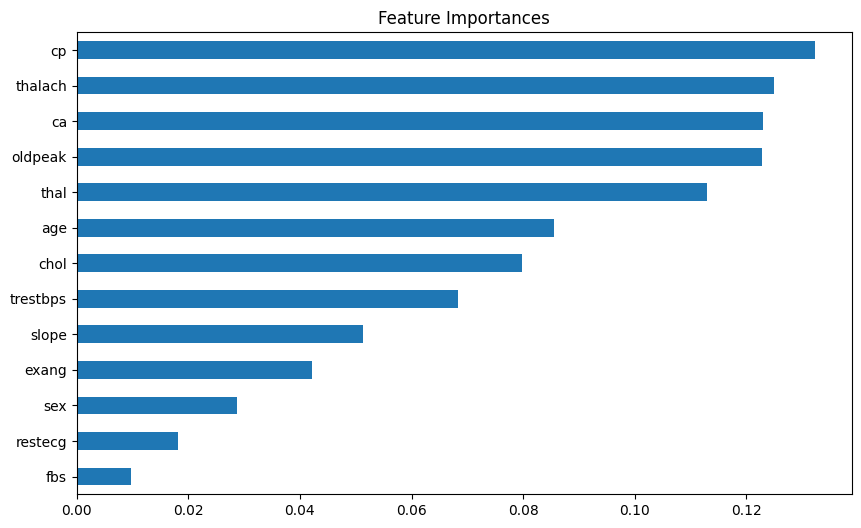

Decision Tree CV Accuracy: 1.00 (+/- 0.00)
Random Forest CV Accuracy: 1.00 (+/- 0.01)


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
import graphviz
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("/content/heart.csv")
X = df.drop("target", axis=1)
y = df["target"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 1. Train Decision Tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Visualize Tree
dot_data = tree.export_graphviz(clf, out_file=None,
                                 feature_names=X.columns,
                                 class_names=["No Disease", "Disease"],
                                 filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph.render("decision_tree")

# 2. Control Overfitting - Max Depth Tuning
train_scores = []
test_scores = []
depths = range(1, 21)

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.plot(depths, train_scores, label='Train Accuracy')
plt.plot(depths, test_scores, label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Overfitting Analysis')
plt.legend()
plt.grid(True)
plt.show()

# 3. Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# 4. Feature Importances
importances = rf.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.sort_values().plot(kind='barh', figsize=(10,6), title='Feature Importances')
plt.show()

# 5. Cross-validation Evaluation
dt_cv_scores = cross_val_score(clf, X, y, cv=5)
rf_cv_scores = cross_val_score(rf, X, y, cv=5)
print("Decision Tree CV Accuracy: %0.2f (+/- %0.2f)" % (dt_cv_scores.mean(), dt_cv_scores.std() * 2))
print("Random Forest CV Accuracy: %0.2f (+/- %0.2f)" % (rf_cv_scores.mean(), rf_cv_scores.std() * 2))
